In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../'))

In [2]:
import techind as ti
import pandas as pd

In [3]:
for i in vars(ti):
    print(i)

__name__
__doc__
__package__
__loader__
__spec__
__path__
__file__
__cached__
__builtins__
exponentialMovingAverage
t3MovingAverage
weightedMovingAverage
trippleExponentialMovingAverage
triangularMovingAverage
simpleMovingAverage
mesaAdaptiveMovingAverage
kaufmanAdaptiveMovingAverage
doubleExponentialMovingAverage


In [4]:
df = pd.read_pickle('../data/test_data01.pkl')
df.tail()

,adjclose
date,
2019-12-24,0.55
2019-12-26,0.62
2019-12-27,0.57
2019-12-30,0.57
2019-12-31,0.59


In [11]:
df['SMA'] = ti.weightedMovingAverage(40, df['adjclose'].values)
df['EMA'] = ti.trippleExponentialMovingAverage(40, df['adjclose'].values)
df['WMA'] = ti.triangularMovingAverage(40, df['adjclose'].values)
df['SMA'] = ti.simpleMovingAverage(40, df['adjclose'].values)
df['MAMA'],df['FAMA'] = ti.mesaAdaptiveMovingAverage(df['adjclose'].values, df['adjclose'].values, .5, .05, 50)
df['KAMA'] = ti.kaufmanAdaptiveMovingAverage(40, 2, 30, df['adjclose'].values)
df['EMA'] = ti.exponentialMovingAverage(40, df['adjclose'].values)
df['DEMA'] = ti.doubleExponentialMovingAverage(40, df['adjclose'].values)
df['T3MA'] = ti.t3MovingAverage(40, .01, df['adjclose'].values)

<Axes: xlabel='date'>

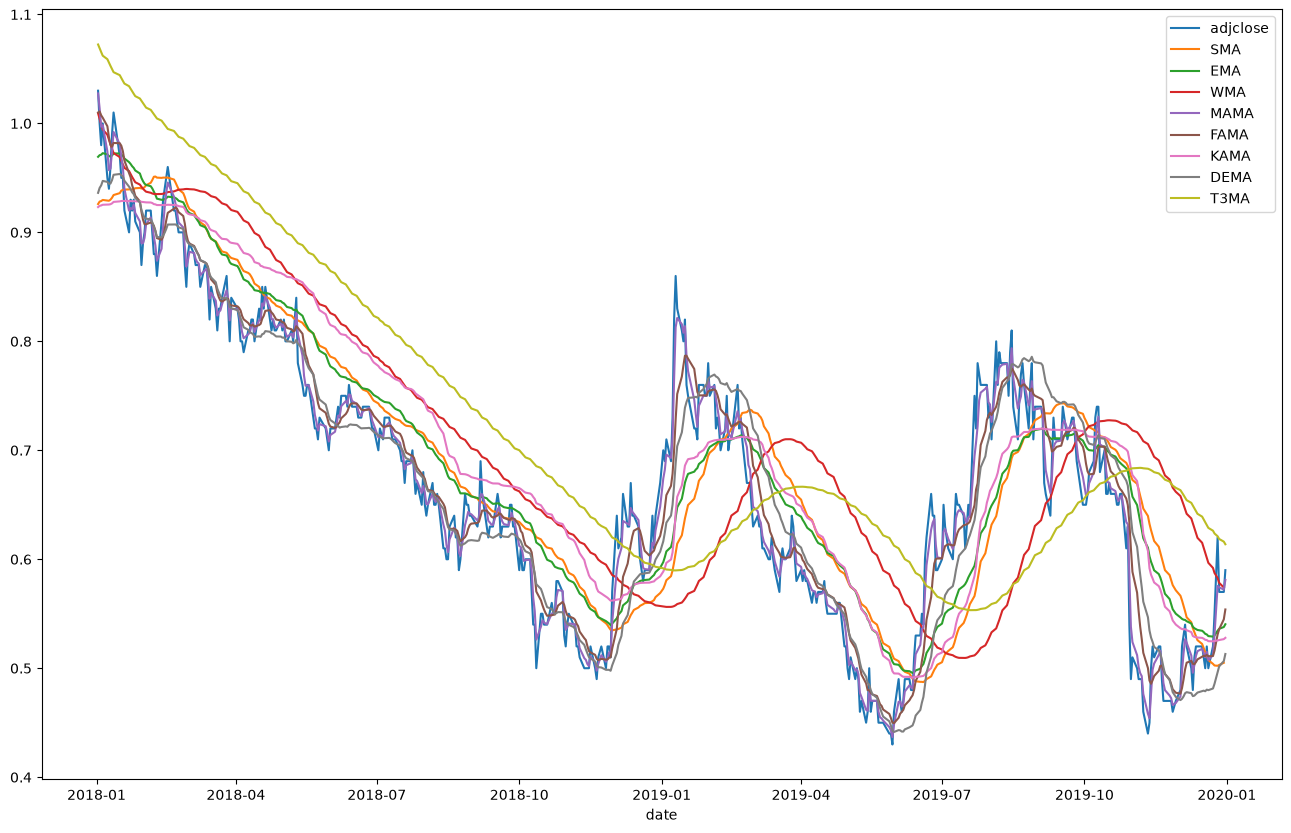

In [12]:
df.loc[df.index > pd.to_datetime("2018-01-01").date()].plot(figsize=(16,10))